# Modeling

This notebook covers the complete machine learning modeling pipeline for the project, including:

* Data Preprocessing
* Feature selection using tree-based models.
* Model experimentation and comparison
* Hyperparameter tunning
* Saving the final model pipeline and configuration. 

----

## Data Preprocessing

To ensure reproducibility, modularity and cleaner experimentation, all preprocessing logic is implemented as reussable functions inside:

    ./src/preprocessing.py

The preprocessing pipeline includes:

* Splitting continuous target value into three classes
* Encoding categorical features
* Feature scaling and normalization
* Train\Test splitting
* Feature engineer utilities

Using centralized preprocessing functions allows the same transformations to be consistentl applied during both training and inference.

----

## Feature Selection

Feature importance is evaluated using tree-based models such as:

* Random Forest
* XGBoost

The most informative features are selected based on importance scores to:

* Reduce noise
* Improve model generalization
* Decrease training time
* Simplify model interpretation

----

## Model Experimentation

Several machine learning models are trained and evaluated, including:

* Logistic Regression
* SVM
* Random Forest
* XGBoost
* CatBoost

Each model is compared using appropriate evaluation metrics such as:

* Accuracy
* F1-Score
* ROC-AUC
* Precision \ Recall

Cross-validation is used to ensure robust evaluation.

----

## Hyperparameter tuning

The best performance models are further optimized using hyperparameter tuning techniques such as:

* GridSearch
* Random Search
* Optuna \ Bayseian Optimization

The tuning process aims to maximize validation performance while preventing overfitting.

----

## Model Saving

The final selected model is exported together with:

* Preprocessing pipeline
* Model parameters
* Feature list
* Training configuration

# Step 1. Data Preprocessing

In this section preprocesssing logic is used from `./src/preprocessing.py`, including:

* Deleteing continuous target classes
* Creating new multiclass-like class `G3_class`
* Creating preprocessor

In [1]:
import pandas as pd
from pathlib import Path
import sys
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)

sys.path.append(str(Path("..").resolve()))

DATA_DIR = Path("../dataset/student")

csv_files = list(DATA_DIR.glob("*.csv"))

csv_files

[WindowsPath('../dataset/student/student-mat.csv'),
 WindowsPath('../dataset/student/student-por.csv')]

In [49]:
df = pd.read_csv(csv_files[1], sep=";")

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,0,yes,no,no,no,yes,yes,yes,no,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,no,yes,yes,yes,yes,yes,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,no,no,yes,yes,no,no,4,3,2,1,2,5,0,11,13,13


In [51]:
import src.preprocessing as preprocessing

df = preprocessing.create_class_target_variable(df)
df = preprocessing.delete_continuous_targets(df)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 31 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   school      649 non-null    str     
 1   sex         649 non-null    str     
 2   age         649 non-null    int64   
 3   address     649 non-null    str     
 4   famsize     649 non-null    str     
 5   Pstatus     649 non-null    str     
 6   Medu        649 non-null    int64   
 7   Fedu        649 non-null    int64   
 8   Mjob        649 non-null    str     
 9   Fjob        649 non-null    str     
 10  reason      649 non-null    str     
 11  guardian    649 non-null    str     
 12  traveltime  649 non-null    int64   
 13  studytime   649 non-null    int64   
 14  failures    649 non-null    int64   
 15  schoolsup   649 non-null    str     
 16  famsup      649 non-null    str     
 17  paid        649 non-null    str     
 18  activities  649 non-null    str     
 19  nursery     649 non

In [52]:
from sklearn.model_selection import train_test_split

X, y = preprocessing.split_X_y(df)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, y_train.shape

((519, 30), (519,))

In [53]:
cat_features = X.select_dtypes(include=['string', 'object']).columns
num_features = X.select_dtypes(include=['int']).columns

preprocessor = preprocessing.create_preprocessor(categorical_features=cat_features,
                                                numerical_features=num_features)

# Step 2. Modeling

This section is dedicated to identifying the best baseline model for further optimization and tuning.

The following models will be evaluated:

* `LogisticRegression`
* `RandomForest`
* `SVC`
* `XGBoost`
* `CatBoost`

`XGBoost` and `CatBoost` use separate pipelines due to their model-specific preprocessing requirements and training strategies. 

The remaining scikit-learn models are combined into a single `GridSearch` pipeline.

At the end of this section all models will be compared using the selected evaluation metrics.

Different estimator types require different processing strategies. To simplify experimentation, a custom preprocessing utility was implemented in `./src/preprocessing.py`, allowing flexible configuration of feature transformation.

----

## Evalution metric.

The Student Performance Dataset (Portuguese language version) conatins 649 rows.

After transforming continuous target variable `G3` into a multiclass target (`G3_class`), a strong class imbalance appeared.

The key business question becomes:

1. Should the model prioritize overall predictive performance of majority classes?
2. Or should it prioritize detecting low-performance students despite the class imbalance?

The answer directly affects the choice of *evaluation metrics*.

----

## Important Trade-Off

There is an important trade-off to consider:

* Optimizing for minority-class detection may reduce overall accuracy and increase false positives.
* Optimizing for majority-class performance may cause the model to ignore the minority class entirely.

The primary optimization objective is minority-class recall.

Missing low-performance students is considered more costly than incorrectly flagging average-performing students.

However, since optimizing recall alone may increase false positives, additional evaluation will include:

* macro F1-score
* confustion matrix analysis

In [54]:
preprocessor_num = preprocessing.create_preprocessor(
    categorical_features=cat_features,
    numerical_features=num_features,
    scale_numeric=True,
    encode_categorical="onehot"
)

preprocessor_tree = preprocessing.create_preprocessor(
    categorical_features=cat_features,
    numerical_features=num_features,
    scale_numeric=False,
    encode_categorical="onehot"
)

preprocessor_catboost = preprocessing.create_preprocessor(
    categorical_features=cat_features,
    numerical_features=num_features,
    scale_numeric=False,
    encode_categorical="passthrough"
)

----

## Scikit-learn inbuilt models

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, GridSearchCV

baseline_pipeline = Pipeline([
    ("preprocessor", None),
    ("model", None)
])

param_grid = [
    # ========================= Logistic Regresssion =========================
    {
        "model": [LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")],
        "preprocessor": [preprocessor_num],
        "model__C": [0.01, 0.1, 1, 10],
        "model__l1_ratio": [0],
        "model__solver": ["newton-cholesky", "lbfgs"]
    },

    # ========================= SVM =========================
    {
        "model": [SVC(random_state=42, class_weight="balanced")],
        "preprocessor": [preprocessor_num],
        "model__C": [0.01, 0.1, 1, 10],
        "model__kernel": ["linear", "rbf"],
        "model__gamma": ["scale", "auto"]
    },

     # ========================= Random Forest =========================
    {
        "model": [RandomForestClassifier(random_state=42, class_weight="balanced")],
        "preprocessor": [preprocessor_tree],
        "model__n_estimators": [100, 300, 500],
        "model__max_depth": [None, 10, 20, 50],
        "model__min_samples_split": [2, 5]
    }
]

cv = StratifiedKFold(random_state=42, shuffle=True, n_splits=3)

baseline_grid = GridSearchCV(
    estimator=baseline_pipeline,
    param_grid=param_grid,
    scoring="recall_macro",
    n_jobs=-1,
    cv=cv
)

baseline_grid.fit(X_train, y_train)

baseline_model = baseline_grid.best_estimator_
baseline_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [8]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
)
import src.modeling as modeling

y_pred = baseline_model.predict(X_test)

baseline_metrics_df = modeling.calc_model_metrics(y_test=y_test, y_pred=y_pred)

baseline_metrics_df

,metric,value
0,precision macro,0.543561
1,recall macro,0.689010
2,f1 macro,0.549800
3,balanced accuracy,0.689010


In [9]:
type(y_pred)

numpy.ndarray

In [10]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.19      0.75      0.30         4
           1       0.79      0.54      0.64        71
           2       0.65      0.78      0.71        55

    accuracy                           0.65       130
   macro avg       0.54      0.69      0.55       130
weighted avg       0.71      0.65      0.66       130



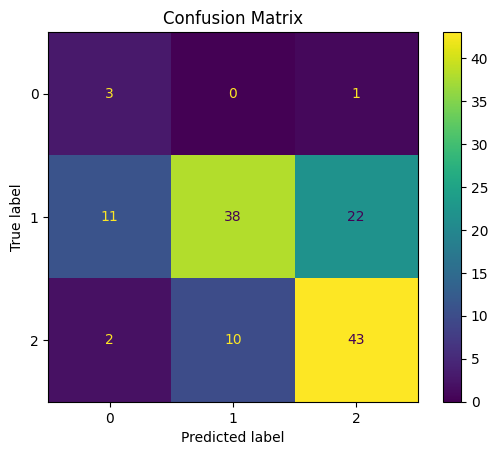

In [11]:
baseline_cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(baseline_cm).plot()

plt.title(f"Confusion Matrix")
plt.show()

### Baseline Models Conclusion

Among the evaluated classical scikit-learn models, `SVC` demonstrated the strongest overall performance under the selected imbalance-oriented evalution strategy.

The model achieved:

* `Precision Macro`: 0.54
* `Balanced Accuracy`: 0.69
* `Recall Macro`: 0.69
* `F1 Macro`: 0.55

The selected optimization strategy focused on `recall_macro`, prioritizing the detection of minority-class students over maximizing overall accuracy.

This decision was motivated by the business objective of identifying potentially low-performing students early enough for possible educational intervention.

The classification report and confusion matrix show that the model successfully learned to detect the minority class entirely.

However this improvemennt introduced a noticeable trade-off:

* minority-class precision remained relatively low (`0.19`)
* the model generated a considerable number of false positive predictions for `Class 0 (C)`

This behavior is expected under severe multiclass imbalance and reflects the model's increased sensitivity toward minority-class detection.

The confusion matrix also indicates that the model still struggles to clearly separate majority classes (`Class 1` and `Class 2`), producing multiple cross-class missclassifications.

Overall the baseline experiments demonstrate that evaluation metric selection strongly influences model behavior in imbalanced multiclass problems.

While `SVC` achieved the best baseline performance among the tested scikit-learn models, further evaluation using gradient boosting methods such as `XGBoost` and `CatBoost` is required to determine whether stronger minority-class handling and better class separation can be achieved. 

## XGBoost

In [12]:
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight

sample_weight = compute_sample_weight(class_weight="balanced", y=y_train)

xgboost_pipeline = Pipeline([
    ("preprocessor", preprocessor_tree),
    ("model", XGBClassifier(
        random_state=42,
        num_class=3,
        objective="multi:softprob",
        eval_metric="mlogloss"
    ))
])

param_grid = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [3, 5, 7, 9],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__subsample": [0.7, 0.9, 1.0],
    "model__colsample_bytree": [0.8, 0.9, 1.0]
}

cv = StratifiedKFold(n_splits=3, random_state=42, shuffle=True)

xgb_grid = GridSearchCV(
    estimator=xgboost_pipeline,
    param_grid=param_grid,
    scoring="recall_macro",
    cv=cv,
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train, model__sample_weight=sample_weight)
xgb_model = xgb_grid.best_estimator_

xgb_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [13]:
y_pred = xgb_model.predict(X_test)

xgb_metrics_df = modeling.calc_model_metrics(y_test=y_test, y_pred=y_pred)

xgb_metrics_df

,metric,value
0,precision macro,0.582285
1,recall macro,0.652027
2,f1 macro,0.594982
3,balanced accuracy,0.652027


In [14]:
print(classification_report(y_true=y_test, y_pred=y_pred))

              precision    recall  f1-score   support

           0       0.25      0.50      0.33         4
           1       0.83      0.62      0.71        71
           2       0.67      0.84      0.74        55

    accuracy                           0.71       130
   macro avg       0.58      0.65      0.59       130
weighted avg       0.74      0.71      0.71       130



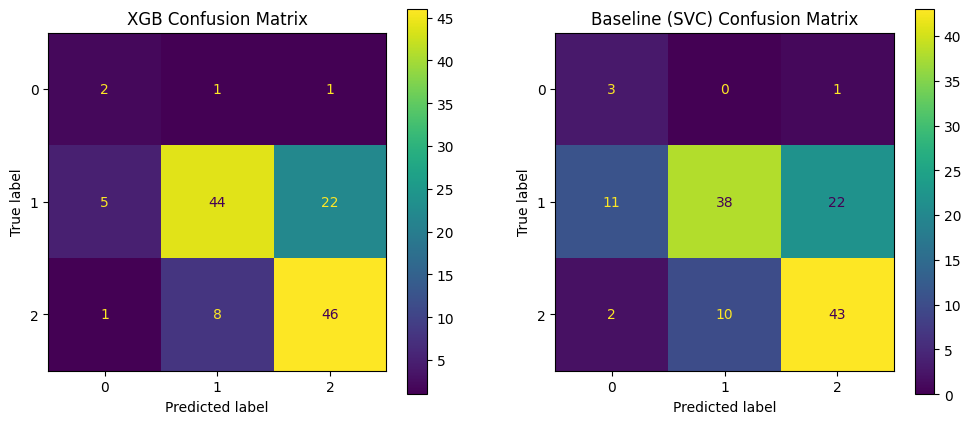

In [15]:
xgb_cm = confusion_matrix(y_true=y_test, y_pred=y_pred)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
ConfusionMatrixDisplay(xgb_cm).plot(ax=axes[0])
ConfusionMatrixDisplay(baseline_cm).plot(ax=axes[1])

axes[0].set_title("XGB Confusion Matrix")
axes[1].set_title("Baseline (SVC) Confusion Matrix")
plt.show()

### XGboost Conclusion

After evaluating the baseline *XGBoost* model with class imbalance handling through sample weighting, the model demonstartes more stable and balanced performance compared to the best previous baseline model, which was *scikit-learn SVC*.

The confusion matrix analysis showed that XGBoost significantly reduced the number of false positive predictions for the minority class while maintaining acceptable recall performance. Compared to SVC, the model produced cleaner class separation and improved prediction stability for majority classes.

Although the minority class recall slightly decreased compared to the SVC model, XGBoost achieved a more balanced trade-off between sensitivity and precision, indicating better overall calibration and generalization ability.

At this stage, XGBoost can be considered a strong candidate for further hyperparameter optimization. However, final model selection cannot yet be performed, since *CatBoost* evaluation and additional tuning stages are still required.

## CatBoost

In [16]:
from catboost import CatBoostClassifier
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

weigths = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

weigths

array([10.8125    ,  0.61347518,  0.78280543])

In [17]:
cat_features_idx = [
    X_train.columns.get_loc(col)
    for col in cat_features
]

cat_features_idx

[0, 1, 3, 4, 5, 8, 9, 10, 11, 15, 16, 17, 18, 19, 20, 21, 22]

In [18]:
%%time

from catboost import Pool

train_pool = Pool(
    data=X_train,
    label=y_train,
    cat_features=cat_features_idx
)

test_pool = Pool(
    data=X_test,
    label=y_test,
    cat_features=cat_features_idx
)

cat_model = CatBoostClassifier(
    loss_function="MultiClass",
    eval_metric="TotalF1",
    class_weights=weigths,
    random_state=42,
    logging_level="Silent",
    thread_count=-1
)

param_grid = {
    "depth": [4, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1],
    "iterations": [200, 400],
    "l2_leaf_reg": [1, 3, 5]
}

catboost_grid = cat_model.grid_search(
    param_grid=param_grid,
    X=train_pool,
    cv=3,
    stratified=True,
    verbose=0,
    partition_random_seed=42
)

y_pred = cat_model.predict(X_test)

CPU times: total: 3min 35s
Wall time: 6min 24s


In [19]:
catboost_metric_df = modeling.calc_model_metrics(y_test=y_test, y_pred=y_pred)
catboost_metric_df

,metric,value
0,precision macro,0.667383
1,recall macro,0.669441
2,f1 macro,0.663850
3,balanced accuracy,0.669441


In [20]:
print(classification_report(y_true=y_test, y_pred=y_pred))

              precision    recall  f1-score   support

           0       0.50      0.50      0.50         4
           1       0.83      0.69      0.75        71
           2       0.67      0.82      0.74        55

    accuracy                           0.74       130
   macro avg       0.67      0.67      0.66       130
weighted avg       0.75      0.74      0.74       130



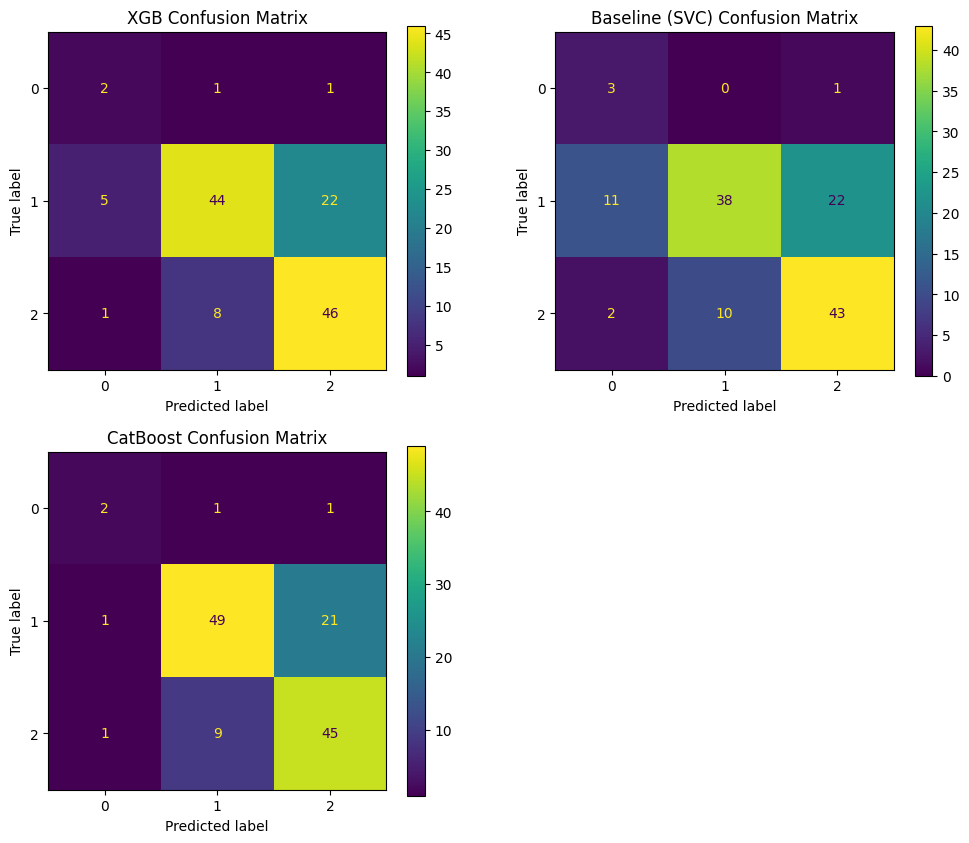

In [21]:
catboost_cm = confusion_matrix(y_true=y_test, y_pred=y_pred)

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))

axes = axes.flatten()

ConfusionMatrixDisplay(xgb_cm).plot(ax=axes[0])
ConfusionMatrixDisplay(baseline_cm).plot(ax=axes[1])
ConfusionMatrixDisplay(catboost_cm).plot(ax=axes[2])

axes[0].set_title("XGB Confusion Matrix")
axes[1].set_title("Baseline (SVC) Confusion Matrix")
axes[2].set_title("CatBoost Confusion Matrix")

fig.delaxes(axes[3])
plt.show()

### CatBoost Conclusion

After evaluating the baseline CatBoost model with class imbalance handling trhough class weightning, the model demostrates strong and well-balanced performance across all classes compared to the previously evaluated baseline models (SVC and XGBoost).

The confusion matrix analysis shows that CatBoost achieves a stable class separation, with particulary strong performance on the majority and mid-frequency classes. The model correctly captures a large proportion of class 1 and class 2 samples, while maintaining a reasonable recall for the minority class despite its extremely limited representation.

Compared to SVC, CatBoost significantly improces overall balance between classes and reduces misclassification in the dominant class, which previously showed instability uder linear and kernel-based approaches. Compared to XGBoost, CatBoost provides slightly better recall for class 1 and a more balanced distribution of errors across classes, indicating improved robustness.

Altough the minority class (class 0) remains challenging due to severe underrepresentation, CatBoost maintains comparable performance to XGBoost wihtout collapsing into majority-class bias, demonstrating good generalization behavior under imbalance conditions. 

At this stage, CatBoost can be considered the most stable and promising candidate among evaluated models. It will therefore be selected for further hyperparameter tuning and final model optimization before conducting the final cross-model comparison.

----

## Final Model Selection Conclusion

After evaluating multiple baseline models, including Logistic Regression, Random Forest, SVC, XGBoost and CatBoost, the final model selection was performed based on macro-oriented evaluation metrics and confusion matrix analysis due to the severe multiclass imbalance present in the dataset.

Among the evaluated approaches, CatBoost demostrated the most balanced overall performance across classes. While SVC model achieved the highest recall for the minority class, it introduced a significant trade-off by reducing predictive stability for the majorty classes. XGBoost improved the overall class balance and generalization ability compared to SVC, but CatBoost provided the most stable distribution of predictions and better robustness across class boundaries.

In addition, CatBoost natively handles categorical features and class imbalance more effectively, reducing the need for aggressive preprocessing and making the training pipeline simplier and more reliable for tabular data.

Based on the overall evaluation results, **CatBoost** was selected as the primary candidate for further hyperparameter optimization and final model development. 

----

# Step 3. Model Tuning

In [22]:
catboost_grid["params"]

{'depth': 6, 'learning_rate': 0.05, 'l2_leaf_reg': 3, 'iterations': 200}

In [23]:
%%time

param_grid = {
    "depth": [5, 6, 7],
    "learning_rate": [0.03, 0.05, 0.07],
    "iterations": [150, 200, 300],
    "l2_leaf_reg": [2, 3, 4],
    "random_strength": [1, 2, 5]
}

classes = np.unique(y_train)

weights = compute_class_weight(class_weight="balanced", y=y_train, classes=classes)

train_pool = Pool(
    data=X_train,
    label=y_train,
    cat_features=cat_features_idx
)

test_pool = Pool(
    data=X_test,
    label=y_test,
    cat_features=cat_features_idx
)

catboost_model = CatBoostClassifier(
    loss_function="MultiClass",
    eval_metric="TotalF1",
    class_weights=weights,
    random_state=42,
    logging_level="Silent",
    thread_count=-1,
    od_type="Iter",
    od_wait=50
)

catboost_random_search = catboost_model.randomized_search(
    param_distributions=param_grid,
    X=train_pool,

    n_iter=100,
    cv=3,
    stratified=True,
    partition_random_seed=42,
    verbose=False
)

print(f"Best Parameters: {catboost_random_search["params"]}")

Best Parameters: {'random_strength': 1, 'depth': 7, 'learning_rate': 0.03, 'l2_leaf_reg': 2, 'iterations': 150}
CPU times: total: 1min 58s
Wall time: 2min 27s


In [24]:
y_pred = catboost_model.predict(test_pool)

print(classification_report(y_true=y_test, y_pred=y_pred))

              precision    recall  f1-score   support

           0       0.67      0.50      0.57         4
           1       0.78      0.66      0.72        71
           2       0.64      0.78      0.70        55

    accuracy                           0.71       130
   macro avg       0.70      0.65      0.66       130
weighted avg       0.72      0.71      0.71       130



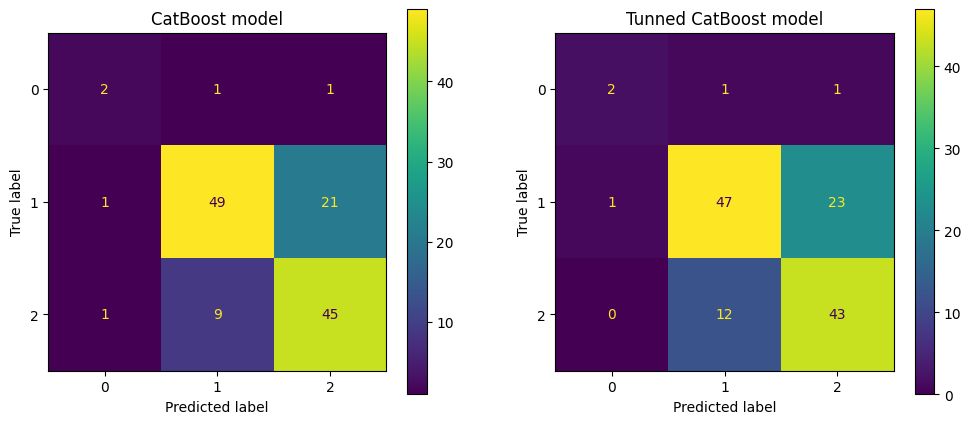

In [25]:
catboost_tunned_cm = confusion_matrix(y_true=y_test, y_pred=y_pred)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

axes = axes.flatten()

ConfusionMatrixDisplay(catboost_cm).plot(ax=axes[0])
ConfusionMatrixDisplay(catboost_tunned_cm).plot(ax=axes[1])

axes[0].set_title("CatBoost model")
axes[1].set_title("Tunned CatBoost model")

plt.show()

In [26]:
catboost_tunned_metric_df = modeling.calc_model_metrics(y_test=y_test, y_pred=y_pred)

catboost_tunned_metric_df

,metric,value
0,precision macro,0.697264
1,recall macro,0.647930
2,f1 macro,0.664635
3,balanced accuracy,0.647930


In [27]:
catboost_metric_df

,metric,value
0,precision macro,0.667383
1,recall macro,0.669441
2,f1 macro,0.663850
3,balanced accuracy,0.669441


## Final CatBoost Tuning Conclusion

After hyperparameter tuning, the CatBoost model did not show meaningful improvement compared to the baseline configuration. The changes in performance were marginal and mainly resulted in small trade-offs between classes rather than a clear overall gain.

This suggests that the model has likely reached a performance plateau given the current feature set and data limitations. Further tuning is unlikely to significantly improve results.

The next step is to move to model interpretation and error analysis, including feature importance and misclassification review.

# Step 4. Feature Importance and Error analysis

In this section, error analysis is performed to understand limitations and errors of the model.

First of all, feature importance is checked. It helps to identify possible weak or noisy featues

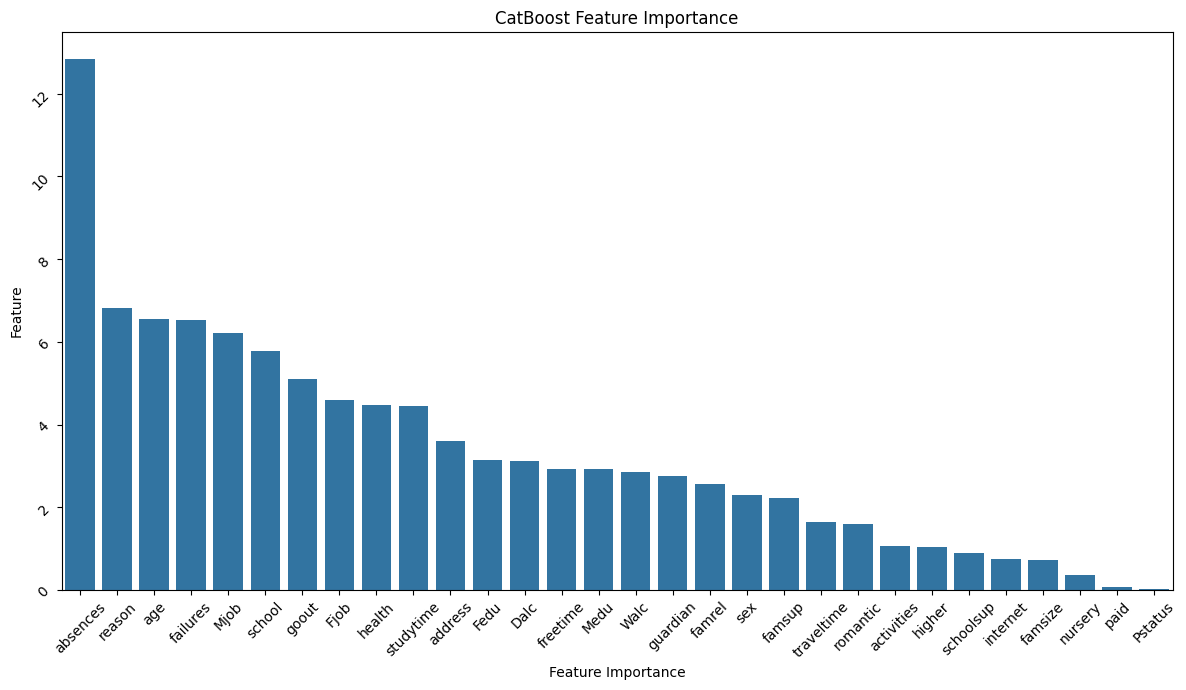

In [55]:
# Rewrite model's variable name
selected_catboost_model = cat_model

feature_importance = selected_catboost_model.get_feature_importance()

importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": feature_importance
}).sort_values(by="importance", ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(data=importance_df, x='feature', y='importance')

plt.tick_params(rotation=45)
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("CatBoost Feature Importance")

plt.tight_layout()
plt.show()

In [47]:
importance_df

,feature,importance
29,absences,12.842855
10,reason,6.809717
2,age,6.560648
14,failures,6.540791
8,Mjob,6.223037
0,school,5.785493
25,goout,5.114027
9,Fjob,4.595729
28,health,4.478515
13,studytime,4.449030


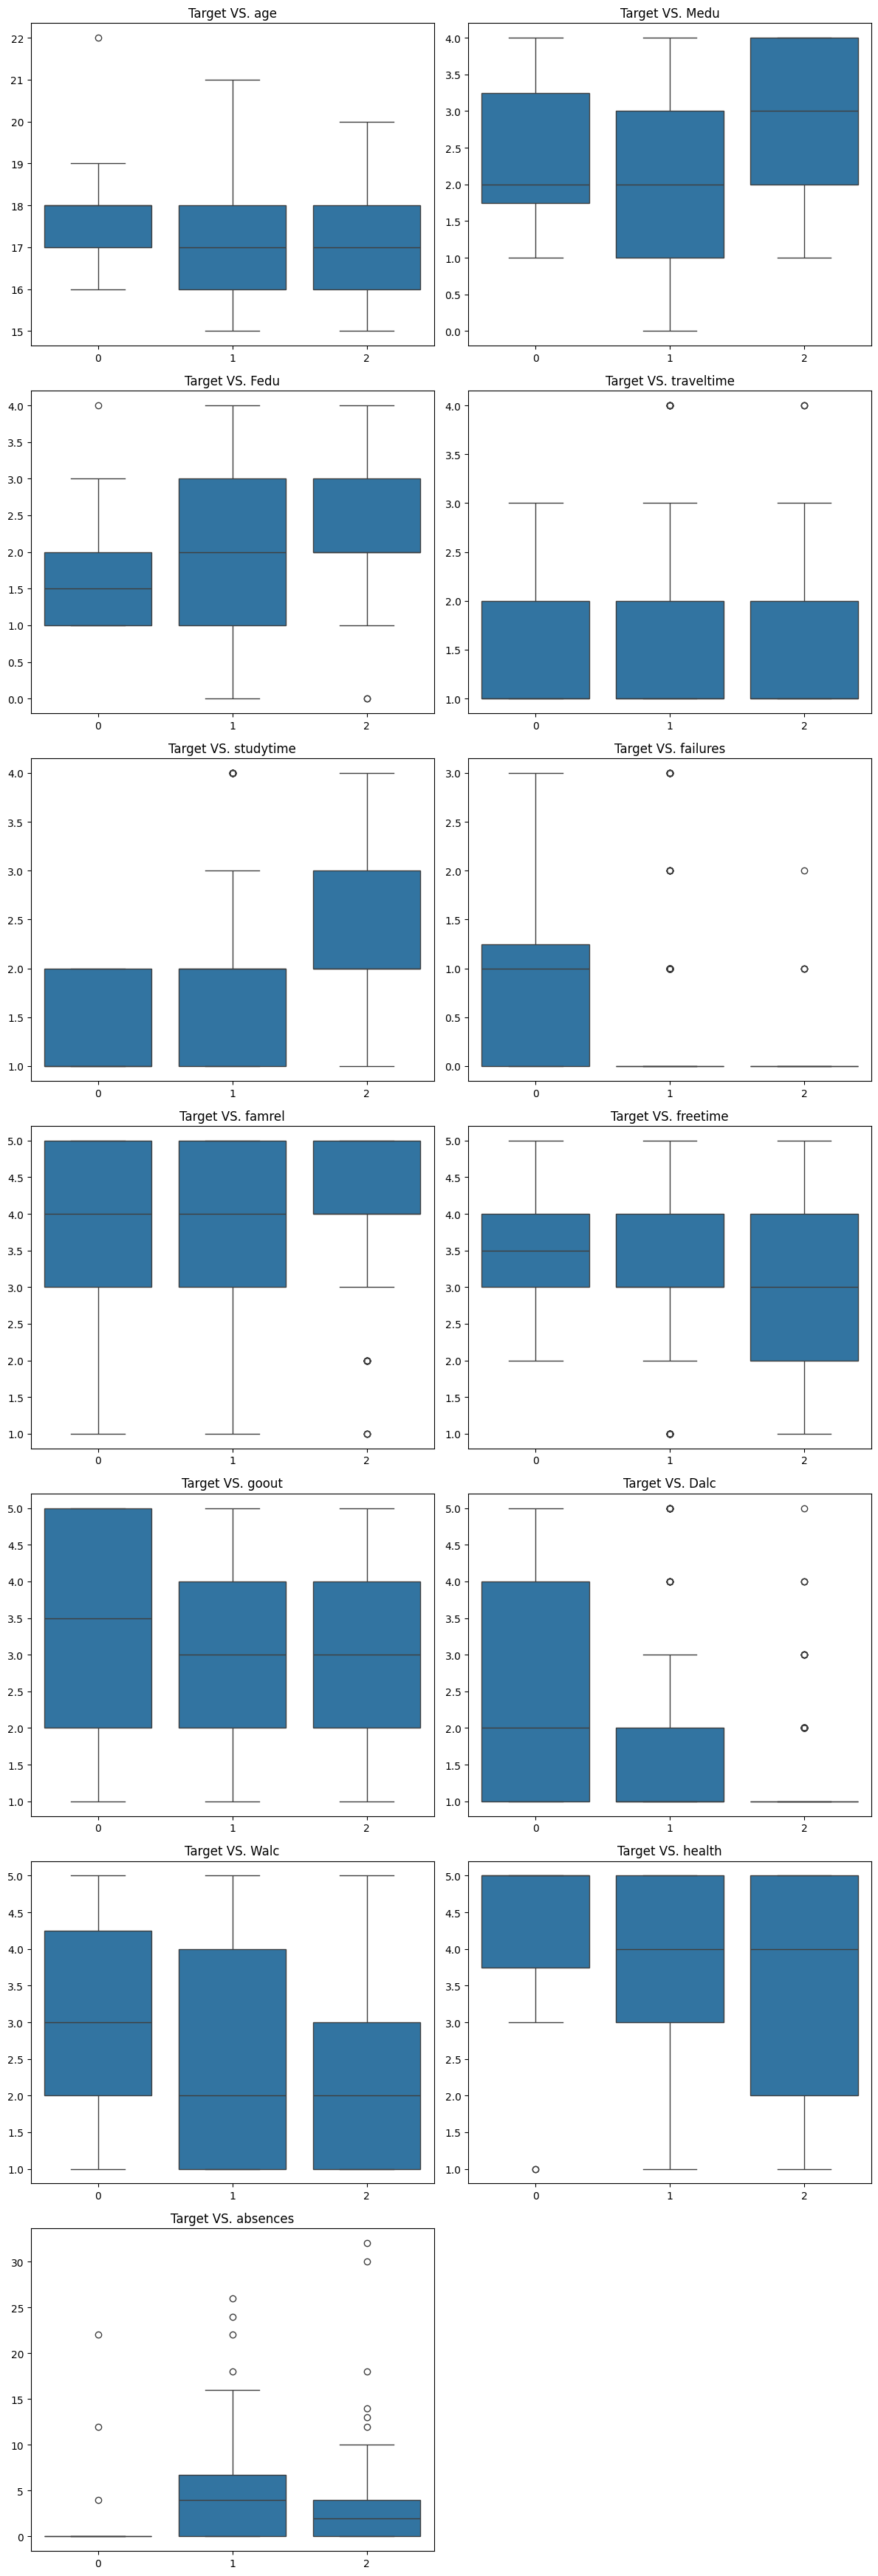

In [48]:
features_to_check = df.select_dtypes(include=["int"]).columns.tolist()

n_cols = 2
n_rows = (len(features_to_check) + n_cols -1) // 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, n_rows*5))

axes = axes.flatten()

for i, col in enumerate(features_to_check):
    sns.boxplot(data=X_train, x=y_train, y=col, ax=axes[i])
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
    axes[i].set_title(f"Target VS. {col}")

for j in range(len(features_to_check), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Based on boxplot analysis, there are some noisy features that may overlap with each other. 

Most visible features are:

* `Medu`
* `traveltime`
* `studytime`
* `famrel`

Possible solution is to experiment with creating new features to increase feature separation. If after, boxplot will show a better class separation, these features can be used to train a new *CatBoost* model.

In [34]:
catboost_cm

array([[ 2,  1,  1],
       [ 1, 49, 21],
       [ 1,  9, 45]])

In [35]:
catboost_tunned_cm

array([[ 2,  1,  1],
       [ 1, 47, 23],
       [ 0, 12, 43]])

In [36]:
xgb_cm

array([[ 2,  1,  1],
       [ 5, 44, 22],
       [ 1,  8, 46]])

In [37]:
baseline_cm

array([[ 3,  0,  1],
       [11, 38, 22],
       [ 2, 10, 43]])

In [38]:
# from sklearn.linear_model import LogisticRegression
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.svm import SVC
# from xgboost import XGBClassifier

# param_grid = [
#     {
#         "model": [LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")],
#         "model__C": [0.1, 1, 10],
#         "model__solver": ["lbfgs"],

#         "preprocessor": [preprocessing.create_preprocessor(
#             categorical_features=cat_features,
#             numerical_features=num_features,
#             scale_numeric=True,
#             encode_categorical="onehot"
            
#         )]
#     },
#     {
#         "model": [RandomForestClassifier(random_state=42, class_weight="balanced")],
#         "model__n_estimators": [100, 200],
#         "model__max_depth": [None, 10, 20],
#         "model__min_samples_split": [2, 5]
#     },
#     {
#         "model": [SVC(random_state=42, class_weight="balanced")],
#         "model__C": [0.1, 1, 10],
#         "model__kernel": ["linear", "rbf"],
#         "model__gamma": ["scale"]
#     },
#     {
#         "model": [XGBClassifier(random_state=42, eval_metric="mlogloss")],
#         "model__n_estimators": [100, 200],
#         "model__max_depth": [3, 5, 7],
#         "model__learning_rate": [0.01, 0.1],
#         "model__subsample": [0.8, 1.0],
#         "model__colsample_bytree": [0.8, 1.0]
#     }
    
# ]

In [39]:
# models = {
#     "logreg": {
#         "model": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
#         "params": [
#             {
#             "model__C": [0.01, 0.1, 1, 10, 100],
#             "model__l1_ratio": [0, 0.5, 1],
#             "model__solver": ["saga"]
#             },
#             "model__C": [0.11]
#         ]
#     }
# }

In [40]:
# from sklearn.model_selection import GridSearchCV, StratifiedKFold

# cv = StratifiedKFold(random_state=42, n_splits=5, shuffle=True)

# grid = GridSearchCV(
#     estimator=pipeline,
#     scoring="f1_macro",
#     param_grid=param_grid,
#     cv=cv,
#     n_jobs=-1
# )

# grid.fit(X_train, y_train)